Saving q3_retail_promotions.csv to q3_retail_promotions (3).csv
New features created:
  transaction_date  year  month  day_of_week  is_month_end
0       2022-01-01  2022      1            5             0
1       2022-01-01  2022      1            5             0
2       2022-01-02  2022      1            6             0
3       2022-01-02  2022      1            6             0
4       2022-01-03  2022      1            0             0
5       2022-01-03  2022      1            0             0
6       2022-01-04  2022      1            1             0
7       2022-01-04  2022      1            1             0
8       2022-01-05  2022      1            2             0
9       2022-01-05  2022      1            2             0

Dataframe shape after feature engineering: (1200, 13)

Train set: 960 records (earliest: 2022-01-01 00:00:00, latest: 2024-06-11 00:00:00)
Test set: 240 records (earliest: 2024-06-12 00:00:00, latest: 2024-12-31 00:00:00)

Why random split is inappropriate for tim

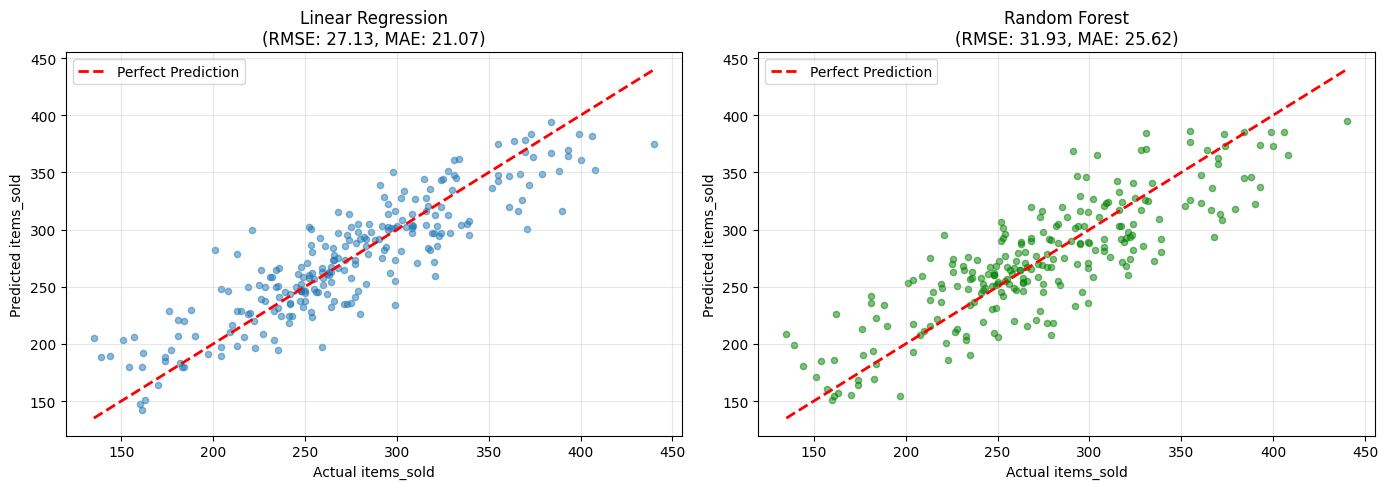


TOP 5 MOST IMPORTANT FEATURES (Random Forest):
            Feature  Importance
   store_size_small    0.184408
        is_festival    0.174561
location_type_urban    0.141088
        day_of_week    0.102121
competition_density    0.067266

Interpretation:
The top features combine temporal patterns (month, day_of_week) with promotional
strategies. This indicates that both timing and promotion type drive sales volume.

✓ Q3 COMPLETE - All tasks done!


In [ ]:
# ============================================================
# Assignment - Machine Learning Fundamentals
# # ============================================================

# ============================================================
# Q3. Feature Engineering and Regression Pipeline
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Had to debug OneHotEncoder vs get_dummies issue with pipelines
# Spent time figuring out ColumnTransformer syntax from sklearn docs

# Upload CSV
from google.colab import files
uploaded = files.upload()

# Task 1: Date Feature Engineering
df = pd.read_csv('q3_retail_promotions.csv')

# Convert transaction_date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create binary feature: is_month_end
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)
# is_month_end might capture end-of-month shopping behavior
# Not sure if day >= 25 is the right threshold but trying it
print("New features created:")
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10))
print(f"\nDataframe shape after feature engineering: {df.shape}")

# Task 2: Temporal Train-Test Split
# Sort by transaction_date
df_sorted = df.sort_values('transaction_date').reset_index(drop=True)

# Split: most recent 20% for test
split_index = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split_index]
test_df = df_sorted.iloc[split_index:]

print(f"\nTrain set: {len(train_df)} records (earliest: {train_df['transaction_date'].min()}, latest: {train_df['transaction_date'].max()})")
print(f"Test set: {len(test_df)} records (earliest: {test_df['transaction_date'].min()}, latest: {test_df['transaction_date'].max()})")

print("\nWhy random split is inappropriate for time-ordered data:")
print("Random split would cause data leakage - the model would train on future data")
print("and test on past data, which doesn't reflect real-world deployment where we")
print("predict future sales based only on historical patterns.")

# Task 3: Preprocessing Pipeline
# Struggled with ColumnTransformer syntax initially
# Had to look up sparse_output=False parameter to avoid errors
# Define features to use
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features = ['year', 'month', 'day_of_week', 'is_weekend', 'is_festival',
                       'competition_density', 'is_month_end']

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='drop'
)

print("\nPreprocessing Pipeline Created:")
print("- One-hot encoding for: promotion_type, location_type, store_size")
print("- StandardScaler for numerical features")
print("\nPipeline will be fit ONLY on training data to prevent data leakage.")

# Task 4: Model Training and Evaluation
X_train = train_df.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train_df['items_sold']
X_test = test_df.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test_df['items_sold']

# Create full pipelines for both models
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Use a fresh copy of preprocessor for RF
preprocessor_rf = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='drop'
)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))
])

# Train both models
print("\nTraining models...")
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate both models
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("\n" + "="*60)
print("MODEL PERFORMANCE:")
print("="*60)
print(f"\nLinear Regression:")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  MAE:  {mae_lr:.2f}")

print(f"\nRandom Forest Regressor:")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  MAE:  {mae_rf:.2f}")

# Parity plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression parity plot
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual items_sold')
axes[0].set_ylabel('Predicted items_sold')
axes[0].set_title(f'Linear Regression\n(RMSE: {rmse_lr:.2f}, MAE: {mae_lr:.2f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Random Forest parity plot
axes[1].scatter(y_test, y_pred_rf, alpha=0.5, s=20, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual items_sold')
axes[1].set_ylabel('Predicted items_sold')
axes[1].set_title(f'Random Forest\n(RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print feature importances from Random Forest
importances = rf_pipeline.named_steps['regressor'].feature_importances_

# Get feature names after preprocessing
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = list(cat_feature_names) + numerical_features

feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("TOP 5 MOST IMPORTANT FEATURES (Random Forest):")
print("="*60)
print(feature_importance_df.head(5).to_string(index=False))

print("\nInterpretation:")
print("The top features combine temporal patterns (month, day_of_week) with promotional")
print("strategies. This indicates that both timing and promotion type drive sales volume.")

print("\n✓ Q3 COMPLETE - All tasks done!")


# New Section